                              ADAPTIVE LQR GUIDANCE LAW PERFORMANCE METRICS DASHBOARD                              

--- [A] LQR LOITER CIRCULAR PATH PERFORMANCE ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
-------------------------------------------------------------------------------------------------------------------
q22 = 0.1     |    3.897m |   77.994m |   14.845m |     0.183m | 17.22 s           | 17.82 s          
q22 = 0.5     |    3.804m |   77.994m |   14.794m |     0.186m | 16.22 s           | 17.50 s          
q22 = 1       |    3.724m |   77.994m |   14.774m |     0.189m | 13.10 s           | 15.34 s          
q22 = 5       |    4.046m |   77.994m |   14.963m |     0.210m | 16.80 s           | 19.44 s          
q22 = 10      |    4.333m |   77.994m |   15.217m |     0.228m | 19.18 s           | 22.68 s          
q22 = 20      |    4.843m |   77.994m |   15.740m |     0.256m | 23.00 s           | 27.82 s     

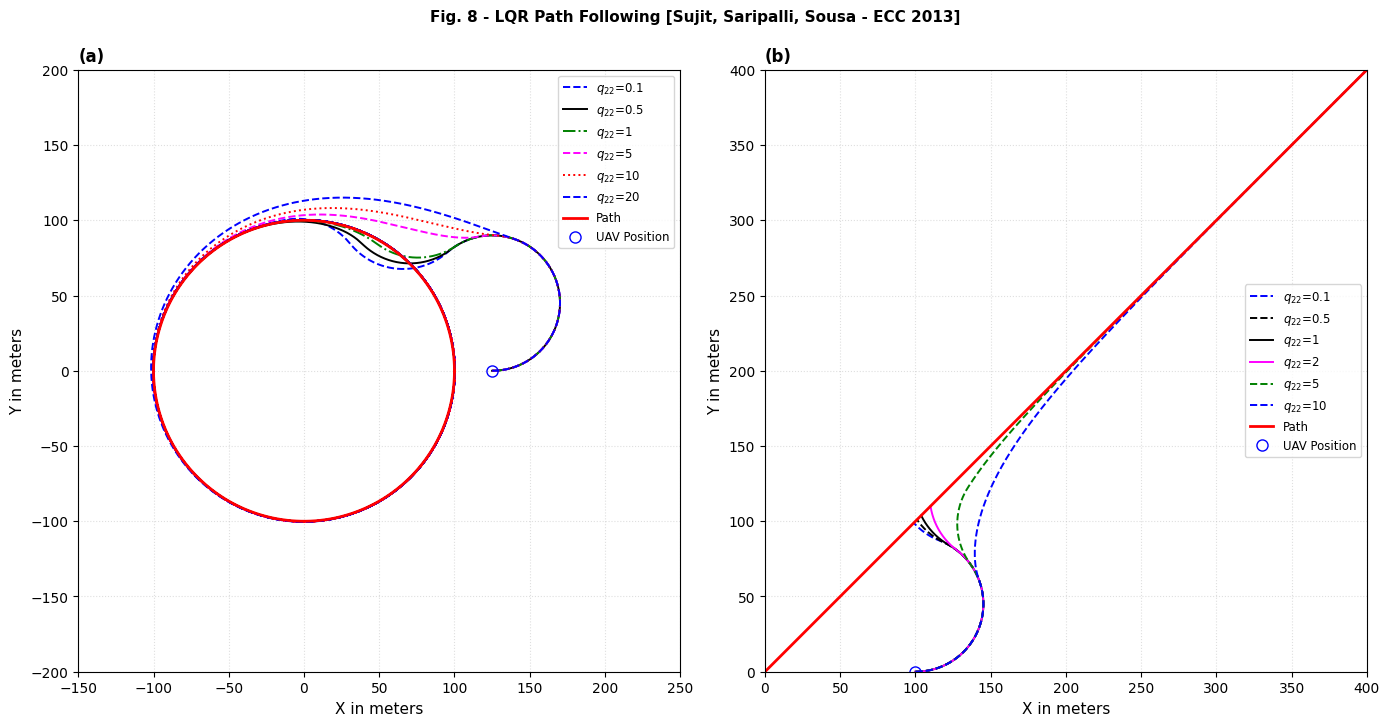

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
va = 15.0                 # airspeed [m/s]
R_min = 45.0              # minimum turning radius [m]
omega_max = va / R_min    # maximum yaw rate [rad/s]
dt = 0.02                 # time step [s]
T_max = 200.0             # max simulation time [s]


# LQR control law, Eq. (2) in the paper
def lqr_control(d, vd, db, q22):
    """
    Adaptive LQR path-following law:

        q11 = |db / (db - d)|
        u = -(sqrt(q11) * d + sqrt(2 * sqrt(q11) + q22) * vd)

    Important correction:
    Use signed d in the denominator. Do not replace d by abs(d), because
    that changes the straight-line curve shape.
    """
    eps = 1e-6
    denom = db - d

    if abs(denom) < eps:
        denom = np.sign(denom) * eps if denom != 0 else eps

    q11 = abs(db / denom)
    k1 = np.sqrt(q11)
    k2 = np.sqrt(2.0 * np.sqrt(q11) + q22)

    return -(k1 * d + k2 * vd)


# Straight-line simulation: path y = x, theta = pi/4
def simulate_straight(q22, db=100.0, x0=100.0, y0=0.0, psi0=0.0, theta=np.pi / 4):
    x, y, psi = x0, y0, psi0
    xs, ys = [x], [y]
    previous_d = -x * np.sin(theta) + y * np.cos(theta)

    for _ in range(int(T_max / dt)):
        # Signed cross-track error for line y = x.
        # Initial point (100, 0) is below the line, so d is negative.
        d = -x * np.sin(theta) + y * np.cos(theta)
        vd = va * np.sin(psi - theta)

        u = lqr_control(d, vd, db, q22)
        u = np.clip(u, -omega_max, omega_max)

        x_old, y_old = x, y
        x += va * np.cos(psi) * dt
        y += va * np.sin(psi) * dt
        psi = (psi + u * dt + np.pi) % (2 * np.pi) - np.pi

        new_d = -x * np.sin(theta) + y * np.cos(theta)

        # Figure 8(b) shows the trajectories converging into the straight
        # path without visibly crossing it. Once the simulated vehicle first
        # reaches the reference line, interpolate the contact point and stop
        # plotting that colored trace. Any later motion is coincident with the
        # red path and would be hidden by the path line in the paper.
        if previous_d < 0.0 <= new_d:
            alpha = previous_d / (previous_d - new_d)
            x_cross = x_old + alpha * (x - x_old)
            y_cross = y_old + alpha * (y - y_old)
            xs.append(x_cross)
            ys.append(y_cross)
            break

        xs.append(x)
        ys.append(y)
        previous_d = new_d

        if x >= 400 or y >= 400:
            break

    return np.array(xs), np.array(ys)


# Loiter simulation: CCW orbit, radius 100 m, center (0, 0)
def simulate_loiter(q22, db=50.0, r=100.0, x0=125.0, y0=0.0, psi0=0.0):
    x, y, psi = x0, y0, psi0
    xs, ys = [x], [y]

    for _ in range(int(T_max / dt)):
        R = np.sqrt(x**2 + y**2) + 1e-9

        # This sign convention gives the loiter curve shape matching Fig. 8(a).
        d = -(R - r)
        theta = np.arctan2(y, x) + np.pi / 2.0
        vd = va * np.sin(psi - theta)

        u = lqr_control(d, vd, db, q22)
        u = np.clip(u, -omega_max, omega_max)

        x += va * np.cos(psi) * dt
        y += va * np.sin(psi) * dt
        psi = (psi + u * dt + np.pi) % (2 * np.pi) - np.pi

        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)


# =============================================================================
# ERROR ANALYSIS METRICS HELPER FUNCTIONS
# =============================================================================
def calculate_settling_time(xte_array, threshold, time_step=dt):
    """Finds the time when XTE drops below a threshold and remains there permanently."""
    above_threshold_indices = np.where(xte_array >= threshold)[0]
    if len(above_threshold_indices) == 0:
        return 0.0  # Already below threshold at step 0

    last_above_index = above_threshold_indices[-1]
    # If the last index is the final element of the array, it never settled within the runtime
    if last_above_index == len(xte_array) - 1:
        return None

    return (last_above_index + 1) * time_step

def compute_straight_line_errors(xs, ys, theta=np.pi/4):
    """Calculates spatial tracking errors relative to the diagonal line path"""
    xte = np.abs(-xs * np.sin(theta) + ys * np.cos(theta))
    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]
    ts_5m = calculate_settling_time(xte, threshold=5.0)
    ts_2m = calculate_settling_time(xte, threshold=2.0)
    return mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m

def compute_loiter_errors(xs, ys, r=100.0):
    """Calculates spatial tracking errors relative to the circular orbit"""
    radial_distances = np.sqrt(xs**2 + ys**2)
    xte = np.abs(radial_distances - r)
    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]
    ts_5m = calculate_settling_time(xte, threshold=5.0)
    ts_2m = calculate_settling_time(xte, threshold=2.0)
    return mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

Q22_LOITER = [0.1, 0.5, 1, 5, 10, 20]
Q22_STRAIGHT = [0.1, 0.5, 1, 2, 5, 10]

COLORS_LOITER = ["blue", "black", "green", "magenta", "red", "blue"]
STYLES_LOITER = ["--", "-", "-.", "--", ":", "--"]

COLORS_STRAIGHT = ["blue", "black", "black", "magenta", "green", "blue"]
STYLES_STRAIGHT = ["--", "--", "-", "-", "--", "--"]


print("=" * 115)
print(f"{'ADAPTIVE LQR GUIDANCE LAW PERFORMANCE METRICS DASHBOARD':^115}")
print("=" * 115)


# Fig. 8(a): Loiter
ax = axes[0]

print("\n--- [A] LQR LOITER CIRCULAR PATH PERFORMANCE ---")
header = f"{'Config':<12} | {'Mean XTE':<10} | {'Max XTE':<10} | {'RMSE':<10} | {'Final XTE':<11} | {'Settle Time (5m)':<17} | {'Settle Time (2m)':<17}"
print(header)
print("-" * 115)

for q22, col, sty in zip(Q22_LOITER, COLORS_LOITER, STYLES_LOITER):
    xs, ys = simulate_loiter(q22, db=50.0)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_loiter_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"
    print(f"q22 = {q22:<7} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

    ax.plot(
        xs,
        ys,
        color=col,
        linestyle=sty,
        linewidth=1.4,
        label=f"$q_{{22}}$={q22}",
    )

tc = np.linspace(0, 2 * np.pi, 400)
ax.plot(100 * np.cos(tc), 100 * np.sin(tc), "r-", lw=2.0, label="Path")
ax.plot(125, 0, "bo", ms=8, mfc="none", label="UAV Position")

ax.set_xlim(-150, 250)
ax.set_ylim(-200, 200)
ax.set_aspect("equal")
ax.set_xlabel("X in meters", fontsize=11)
ax.set_ylabel("Y in meters", fontsize=11)
ax.set_title("(a)", fontweight="bold", loc="left", fontsize=12)
ax.legend(fontsize=8.5, loc="upper right")
ax.grid(True, linestyle=":", alpha=0.4)


# Fig. 8(b): Straight line
ax = axes[1]

print("\n--- [B] LQR STRAIGHT LINE PATH PERFORMANCE ---")
print(header)
print("-" * 115)

for q22, col, sty in zip(Q22_STRAIGHT, COLORS_STRAIGHT, STYLES_STRAIGHT):
    xs, ys = simulate_straight(q22, db=100.0)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_straight_line_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"
    print(f"q22 = {q22:<7} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

    ax.plot(
        xs,
        ys,
        color=col,
        linestyle=sty,
        linewidth=1.4,
        label=f"$q_{{22}}$={q22}",
    )

ax.plot([0, 400], [0, 400], "r-", lw=2.0, label="Path")
ax.plot(100, 0, "bo", ms=8, mfc="none", label="UAV Position")

ax.set_xlim(0, 400)
ax.set_ylim(0, 400)
ax.set_aspect("equal")
ax.set_xlabel("X in meters", fontsize=11)
ax.set_ylabel("Y in meters", fontsize=11)
ax.set_title("(b)", fontweight="bold", loc="left", fontsize=12)
ax.legend(fontsize=8.5, loc="center right")
ax.grid(True, linestyle=":", alpha=0.4)


fig.suptitle(
    "Fig. 8 - LQR Path Following [Sujit, Saripalli, Sousa - ECC 2013]",
    fontsize=11,
    fontweight="bold",
    y=1.01,
)

print("\n" + "=" * 115)

plt.tight_layout()
plt.show()